# Earth's elevation has two peaks. So does Mars's. Same reason?

**EPS 88 · PyEarth.** Open your own copy on DataHub: [click here](https://datahub.berkeley.edu/hub/user-redirect/git-pull?repo=https%3A//github.com/AI4EPS/EPS88_PyEarth&branch=main&urlpath=lab/tree/EPS88_PyEarth/docs/notebooks/03_two_peaks.ipynb).

Ask how high every point on a planet's surface is, and you might expect the answers to crowd around one typical height, the way people's heights do. Earth's do not: they pile up at two levels, with a trough between them that little of the planet sits in. Mars, which has no ocean and no moving plates, has two levels as well.

Today both planets arrive as grids of numbers, one elevation for every one-degree square of the surface. You will find where each planet's two levels sit, map them, measure how much of Earth lies below sea level, and then open a table of earthquakes to see where Earth's old ocean floor goes.

Every place you write something opens with a pencil icon and the words *Your turn*, and is
followed by a cell that already has the shape of the answer written in, with `...` wherever your
code goes. Replace every `...`, run every cell so your answers and figures are
saved in the file, then **download this notebook itself — the `.ipynb` file — and upload it
to Gradescope.** Not a PDF: the marking reads your notebook, and a PDF cannot be read.
In JupyterLab: **File ▸ Download**, or right-click the file in the left-hand panel and choose
**Download**.

Two habits from the first minute. A cell runs when you press **Shift+Enter**, and the notebook
remembers everything it has already run — so when something breaks and you cannot see why,
**Kernel → Restart Kernel and Run All Cells** throws the memory away and rebuilds it from the
top. That is never the wrong thing to do.

## What you'll be able to do

**The science.** Find the two levels of Earth's and Mars's surfaces, see what makes Earth's, and
say what is known and what is still argued about Mars's.

**The code.** Arrays: `.shape` and `.size` · arithmetic on a whole grid at once · `.ravel()` ·
`np.histogram` and `.argmax()` · masks such as `earth < 0`, and `earth[mask]` to keep the cells
where one is True · `plt.imshow` to draw a grid as a picture. Tables: `.info()` · NaN ·
`.median()` · picking rows with a mask · `.groupby()`.

**Eight places where you write something: five in class, three at home.** Each is headed
*Your turn*, and the cell under it already has the shape of the answer written in, with `...`
wherever your code goes. Replace every `...`; a comment beside each one says what it is for. A
`...` left in place is not code, and the cell will not do what you expect until it is replaced.

1. Where do Earth's two levels sit?
2. How much of Earth lies below sea level?
3. Where are Mars's two levels?
4. Where does old ocean floor go?

## Setup

Run the next cell once; you are not expected to follow all of it. It loads `earth` and `mars`,
one elevation in metres for every one-degree square of each planet, the coastlines for maps, and
`quakes`, the USGS catalogue of every earthquake of magnitude 5.5 or more from 2000 to 2025. It
also makes `latitude` and `longitude` — where every cell is, which the elevation files do not
store — `map_edges`, worked out from those two, and `bins`, the edges of 250-metre histogram bins.

Four grids come out of it, and the printout shows why they can be used together: `earth`, `mars`,
`latitude` and `longitude` are all 180 by 360, so the same row and column means the same square
of ground in every one of them.

The counts written into the text below were taken from the catalogue when this notebook was
written. Your run asks USGS for the catalogue as it stands today, so a count may come out one or
two different; the self-checks allow for that.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# house style, set once, so every plot cell below holds only what matters
plt.rcParams.update({"figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True})

CACHE = "https://raw.githubusercontent.com/AI4EPS/EPS88_PyEarth/main/data"

def load():
    """the USGS catalogue of magnitude 5.5 and larger earthquakes, 2000 to 2025: live if the network is up, the copy stored with the course if not"""
    # Ask the live archive first. If it is down, or you are offline, read the copy stored with
    # the course instead, so the notebook still runs.
    try:
        return pd.read_csv("https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&orderby=time-asc"
                       "&starttime=2000-01-01&endtime=2026-01-01&minmagnitude=5.5")
    except Exception as e:
        print("live source unreachable, using the cached copy:", type(e).__name__)
        return pd.read_csv(CACHE + "/" + "week03_2000-01-01_2026-01-01_M5.5.csv")

# The two elevation grids ship with the course, so they are read straight from it. One row per
# degree of latitude (row 0 is the far north), one column per degree of longitude (column 0 is
# 180 degrees west). Earth's come from NOAA's ETOPO relief model, Mars's from the MOLA laser
# altimeter on Mars Global Surveyor.
earth = pd.read_csv(CACHE + "/earth_elevation.csv", header=None).values
mars = pd.read_csv(CACHE + "/mars_elevation.csv", header=None).values

# The elevation files store no positions: a cell's place on the planet is its row and column. So
# write the positions down as two more grids of the same shape, lined up with the first two -
# same row and column, same square of ground. np.arange makes the run of values, np.repeat holds
# each one across a row, np.tile repeats the whole run down the columns.
latitude = np.repeat(np.arange(89.5, -90, -1), 360).reshape(180, 360)    # same all along a row
longitude = np.tile(np.arange(-179.5, 180, 1), 180).reshape(180, 360)    # same all down a column

# Where a map's edges go: half a cell outside the outermost cell CENTRES, which is what latitude
# and longitude hold. Every map below is drawn with it, so the numbers are never typed in twice.
map_edges = [longitude.min() - 0.5, longitude.max() + 0.5, latitude.min() - 0.5, latitude.max() + 0.5]
coast = pd.read_csv(CACHE + "/coastlines.csv")
quakes = load()

bins = np.arange(-10000, 21000, 250)                  # histogram bin edges, 250 m apart

for name, grid in [("earth", earth), ("mars", mars), ("latitude", latitude), ("longitude", longitude)]:
    print(f"{name:10s}", grid.shape, " from", grid.min(), "to", grid.max())
print("coastline points:", len(coast), "  earthquakes:", len(quakes))

live source unreachable, using the cached copy: URLError
earth      (180, 360)  from -9026 to 5824
mars       (180, 360)  from -7682 to 20708
latitude   (180, 360)  from -89.5 to 89.5
longitude  (180, 360)  from -179.5 to 179.5
coastline points: 5261   earthquakes: 12849


## 1. Where do Earth's two levels sit?

`earth` holds one elevation, in metres, for every one-degree square of Earth's surface: 180 rows
of latitude, the far north in row 0, and 360 columns of longitude. That is 64,800
numbers.

A list could hold all of them. Watch what a list does with arithmetic.

In [2]:
heights_list = [0, 1000, 2000]
heights_array = np.array([0, 1000, 2000])

print("list  times 2:", heights_list * 2)
print("array times 2:", heights_array * 2)

list  times 2: [0, 1000, 2000, 0, 1000, 2000]
array times 2: [   0 2000 4000]


The list did not double anything: it made a longer list with the same numbers twice. The array
doubled every one. In weeks 1 and 2 a job like that took a loop over every value; this is what
replaces it.

**Array.** A grid of numbers where every cell is the same kind of thing, so one line of arithmetic changes all of them at once.

So `earth / 1000` would turn every one of Earth's elevations into kilometres in one line. The
array will also say how it is laid out.

In [3]:
print("shape:", earth.shape)   # rows, then columns
print("size: ", earth.size)    # how many numbers that is altogether
print()

# the other three are laid out the same way, which is what lets you use them together
for name, grid in [("mars", mars), ("latitude", latitude), ("longitude", longitude)]:
    print(f"{name:10s} shape {grid.shape}  size {grid.size}")
print()
print("so row 0, column 0 is one place on each:", latitude[0, 0], "north,", longitude[0, 0],
      "east -", earth[0, 0], "m on Earth and", mars[0, 0], "m on Mars")

shape: (180, 360)
size:  64800

mars       shape (180, 360)  size 64800
latitude   shape (180, 360)  size 64800
longitude  shape (180, 360)  size 64800

so row 0, column 0 is one place on each: 89.5 north, -179.5 east - -3314 m on Earth and -1928 m on Mars


`earth.shape` is the layout, rows first: 180 bands of latitude, each one 360 cells of longitude.
`earth.size` is the same numbers counted straight through, all 64,800 of them.

One quantity, measured everywhere on a regular mesh — that is what makes elevation a grid.
Nothing in `earth` stores a latitude or a longitude: the position in the grid *is* the position
on the planet. Row 0 is the far north, column 0 is 180 degrees west, one degree of each per cell.

All four grids report the same `.shape` and the same `.size`, and that is not a coincidence —
it is the reason they can be used together. Row 0, column 0 means the same square of ground in
every one of them, so `earth`, `mars`, `latitude` and `longitude` are four answers about one
place, and any two of them can be asked at once.

Which is why it can be drawn as a picture with no coordinates handed to it. `plt.imshow` puts one
pixel per cell and `extent` says which longitudes and latitudes the picture's four edges are at —
that is `map_edges`, and setup worked it out from `longitude` and `latitude` rather than typing
four numbers in: half a cell outside the outermost cell centres, since those grids hold centres.
`plt.colorbar` adds the key that says what the colours mean.

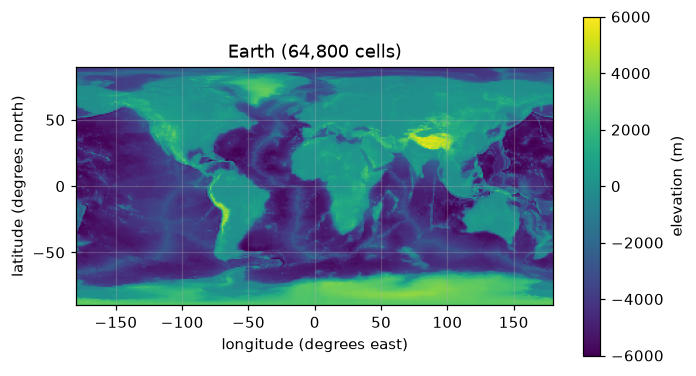

In [4]:
plt.figure(figsize=(7, 4))
plt.imshow(earth, extent=map_edges, vmin=-6000, vmax=6000)   # colours stop at ±6000 m
plt.colorbar(label="elevation (m)")
plt.xlabel("longitude (degrees east)")
plt.ylabel("latitude (degrees north)")
plt.title(f"Earth ({earth.size:,} cells)")
plt.show()

Ocean floor over most of the planet, at what looks like one fairly even depth, with the
continents standing above it and a few bright places higher still.

**Before you run the next cell, decide what you expect.** If you counted how many of the
64,800 cells sit at each height, what shape would the counts make — one hump around a
typical height, the way people's heights do, or something else?

Week 1 counted how many earthquakes fell at each magnitude, and this is the same count asked of
elevations. A histogram wants one long line of numbers, not a grid: `.ravel()` lays the grid out
flat, row after row. `bins`, from setup, holds bin edges 250 metres apart, the same for both
planets, so a level means the same thing each time it is quoted.

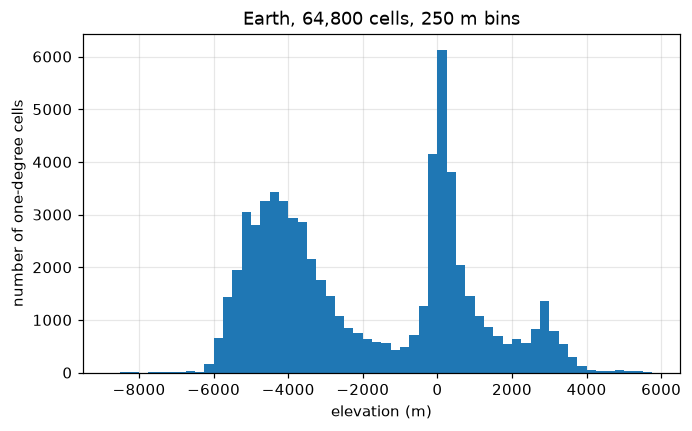

In [5]:
plt.figure(figsize=(7, 4))
plt.hist(earth.ravel(), bins=bins)
plt.xlim(-9500, 6500)                  # the bins run on to 21,000 m, for Mars
plt.xlabel("elevation (m)")
plt.ylabel("number of one-degree cells")
plt.title(f"Earth, {earth.size:,} cells, 250 m bins")
plt.show()

Two humps with a trough between them, one a few kilometres below sea level and one close to it.
A third, much smaller bump sits near 3,000 m — the Antarctic ice sheet. Section 2 comes back to
why it looks bigger here than it should.

What a histogram shows depends on its bins, though. The next cell draws the same grid in only
four bins and counts them too. `np.histogram` does the counting `plt.hist` does and hands back
two arrays: the counts, and the edges the bins run between.

Four bins need five edges, so `edges` is one longer than `counts`. `edges[0]` is where bin 0
starts, `edges[1]` where bin 1 starts, and so on — a number in square brackets picks out one
value by its position. `.argmax()` gives the *position* of the largest value, the way
`list.index(max(list))` does for a list, so that position in the brackets — `edges[counts.argmax()]`
— is where the tallest bin starts.

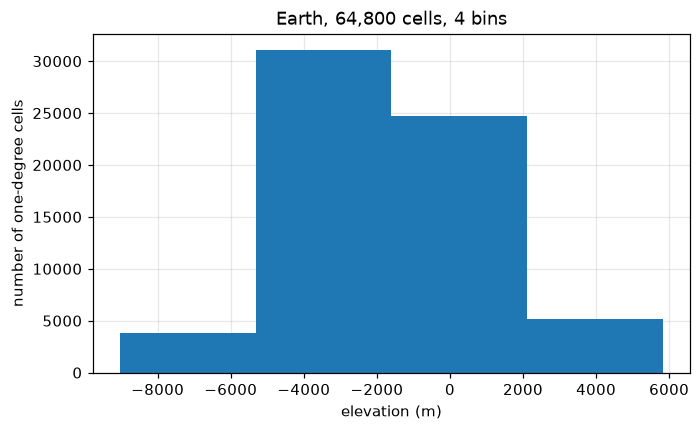

cells in each bin: [ 3788 31078 24759  5175]
bin edges, in m:   [-9026.  -5313.5 -1601.   2111.5  5824. ]
the tallest is bin 1
which starts at    -5313.5 m


In [6]:
plt.figure(figsize=(7, 4))
plt.hist(earth.ravel(), bins=4)
plt.xlabel("elevation (m)")
plt.ylabel("number of one-degree cells")
plt.title(f"Earth, {earth.size:,} cells, 4 bins")
plt.show()

counts, edges = np.histogram(earth.ravel(), bins=4)
print("cells in each bin:", counts)
print("bin edges, in m:  ", edges)
print("the tallest is bin", counts.argmax())
print("which starts at   ", edges[counts.argmax()], "m")

### ✏️ Your turn 1

Four bins give one hump: the counts climb to one tallest bin and fall away, with no dip between
two humps. Is that the planet, or the bins? The cell below counts the same grid in five bins and
prints the edges in kilometres, one line of arithmetic for all six. Then it asks whether the
middle bin is a dip, with a small function: `is_dip(left, middle, right)` is True when the middle
count is lower than the count on its left **and** lower than the count on its right. Fill in the
two comparisons.

So: do five bins show two humps where four showed one?

**Use these names**, because the self-check looks for them: `is_dip`.

In [7]:
counts, edges = np.histogram(earth.ravel(), bins=5)
print("cells in each bin:", counts)
print("bin edges, in km: ", edges / 1000)


def is_dip(left, middle, right):
    """True when the middle count is lower than the counts on both sides of it"""
    return middle < left and middle < right


dip = is_dip(counts[1], counts[2], counts[3])
print("five bins show a dip between two humps:", dip)

cells in each bin: [  159 29036 10627 22351  2627]
bin edges, in km:  [-9.026 -6.056 -3.086 -0.116  2.854  5.824]
five bins show a dip between two humps: True


In [8]:
assert is_dip(2, 1, 3) == True, "is_dip(2, 1, 3) should be True: 1 is lower than both 2 and 3"
assert is_dip(3, 1, 2) == True, "is_dip(3, 1, 2) should be True: 1 is lower than both 3 and 2 — compare middle with each side"
assert is_dip(1, 2, 3) == False, \
    "is_dip(1, 2, 3) should be False: 2 is lower than the 3 on its right but not the 1 on its left, so both tests are needed"
assert is_dip(3, 2, 1) == False, \
    "is_dip(3, 2, 1) should be False: 2 is lower than the 3 on its left but not the 1 on its right, so both tests are needed"
assert dip == True, "dip should be True for the five real counts — is_dip must compare the middle count with each side"
print(f"✓ five bins — the middle bin holds {counts[2]} cells, fewer than the {counts[1]} and {counts[3]} beside it: a dip")

✓ five bins — the middle bin holds 10627 cells, fewer than the 29036 and 22351 beside it: a dip


250-metre bins show two clear humps, so the next step is to find where each one peaks — which
means picking out the cells below the trough and the cells above it, separately.

**Mask.** Comparing an array with a number asks the same question of every cell at once and hands back a grid of True and False.

In [9]:
high = earth > 5000                        # one True or False for every cell
print("the mask:                ", high.shape)
print("the elevations it keeps:", earth[high].shape)
print("the first five of them: ", earth[high][:5])
print()
# the mask came from `earth`; ask the grids that say WHERE
print("they lie between latitude ", latitude[high].min(), "and", latitude[high].max())
print("and between longitude    ", longitude[high].min(), "and", longitude[high].max())
print("how many are north of the equator:", (high & (latitude > 0)).sum())
print("how many are between 60 and 105 east:",
      (high & (longitude > 60) & (longitude < 105)).sum())

the mask:                 (180, 360)
the elevations it keeps: (92,)
the first five of them:  [5460 5045 5024 5509 5176]

they lie between latitude  -26.5 and 42.5
and between longitude     -68.5 and 100.5
how many are north of the equator: 91
how many are between 60 and 105 east: 91


The mask has the same 180 by 360 layout as `earth`. Put it inside square brackets and you get the
elevations themselves, as one long line of numbers — the grid's shape is gone, because the cells
it kept are scattered all over it.

The mask came from `earth`, but `earth[high]`, `latitude[high]` and `longitude[high]` all work,
because the four grids are laid out the same way — which is what the matching shapes in the setup
printout meant. So a mask is not only a way to pull numbers out of the grid that made it. It is a
way to ask where those cells are.

The last two lines ask two questions of every cell at once. `&` joins two masks cell by cell, so
`a & b` is True only where both are, and `.sum()` counts the Trues because Python counts True as
1. Of the 92 cells above 5,000 m, 91 are north of the equator and
the same 91 sit between 60 and 105 degrees east. The highest ground on Earth is
very nearly one place, where India is still driving into Asia; the one cell left over is in the
Andes.

### ✏️ Your turn 2

-1000 m sits in the trough between the two humps, so the deep level is the tallest 250-metre bin
among the cells below -1000 m, and the high level the tallest among the rest.

The cell below picks out the two sets of cells, writes the counting once as the function
`tallest_bin(values, bin_edges)` — everything it needs comes in through its brackets, the way
`check_planet` did in week 2: the elevations themselves rather than a mask, and the edges to
count them into. A bin's middle is its left edge plus half a bin's width, and the width is the
gap between two edges — so the function works whatever bins it is handed. Fill in the two
selections, what to count, and which edge to return.

So: where do Earth's two levels sit?

**Use these names**, because the self-check looks for them: `deep_cells`, `high_cells`,
`earth_deep` and `earth_high`.

In [10]:
deep_cells = earth[earth < -1000]
high_cells = earth[earth >= -1000]


def tallest_bin(values, bin_edges):
    """the middle of the tallest bin among these elevations"""
    counts, edges = np.histogram(values, bins=bin_edges)
    return edges[counts.argmax()] + (bin_edges[1] - bin_edges[0]) / 2


earth_deep = tallest_bin(deep_cells, bins)
earth_high = tallest_bin(high_cells, bins)
print("Earth's deep level:", round(earth_deep), "m")
print("Earth's high level:", round(earth_high), "m")

Earth's deep level: -4375 m
Earth's high level: 125 m


In [11]:
assert deep_cells.max() < -1000 <= high_cells.min(), \
    "deep_cells should hold only elevations below -1000 m, and high_cells only those at -1000 m or above"
assert deep_cells.size + high_cells.size == earth.size, \
    "between them, deep_cells and high_cells should hold every cell of earth: all of it below -1000 m, and all the rest"
assert np.size(earth_deep) == 1 and np.size(earth_high) == 1, \
    "earth_deep and earth_high should each be one number: return one edge, not all of them"
assert -4500 < earth_deep < -4250, \
    "earth_deep should be an elevation in metres: the middle of the tallest bin among deep_cells"
assert 0 < earth_high < 250, \
    "earth_high should be the middle of the tallest bin among high_cells"
print(f"✓ Earth's two levels — {earth_deep:.0f} m and {earth_high:.0f} m, {earth_high - earth_deep:.0f} m apart")

✓ Earth's two levels — -4375 m and 125 m, 4500 m apart


## 2. How much of Earth lies below sea level?

`earth < 0` is a mask like the ones in section 1, and because it holds one True or False for every
one-degree square it can be drawn exactly as the elevations were — a grid is a grid. The coastline
goes on top, as on every map of Earth.

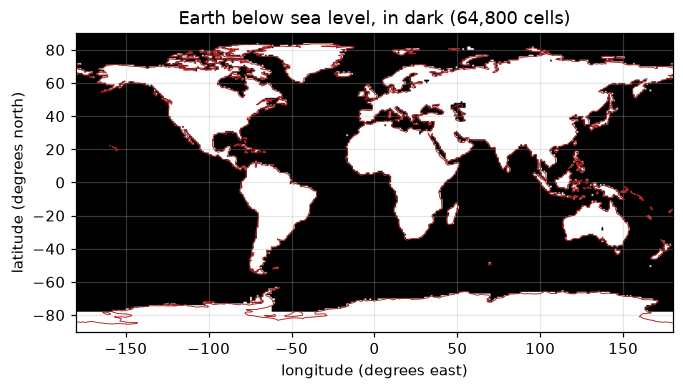

In [12]:
below = earth < 0

plt.figure(figsize=(7, 4))
plt.imshow(below, extent=map_edges, cmap="Greys")    # below sea level is dark
plt.plot(coast.lon, coast.lat, color="firebrick", lw=0.6)
plt.xlabel("longitude (degrees east)")
plt.ylabel("latitude (degrees north)")
plt.title(f"Earth below sea level, in dark ({below.size:,} cells)")
plt.show()

The dark region is one comparison, `earth < 0`, and it comes out as the oceans, with the
coastline along its edge. The map shows where the two levels are, ocean floor and continents;
what makes them is the crust beneath.

**Two kinds of crust.** Ocean crust is thin and dense, continental crust thick and light; both float on the mantle, and the thick, light kind floats higher.

Ocean crust is made at mid-ocean ridges, undersea mountain chains where two plates pull apart,
and sinks back into the mantle at subduction zones, where one plate dives under another.
Continental crust is too buoyant to go down that way, so most of it stays.

Adding up a mask counts its Trues, because Python counts True as 1, so
`below.sum() / below.size` is the share of the cells that lie below sea level. Earth is usually
quoted as about seven-tenths ocean — not quite the same quantity as the share below sea level, but
close — so that is the number to expect.

In [13]:
share_by_cells = below.sum() / below.size

print(f"share of the cells below sea level: {share_by_cells:.3f}")

share of the cells below sea level: 0.660


The grid says 0.660, not seven-tenths. That gap is not rounding.

Every cell counted as one, and the cells are not the same size. A cell is one degree of longitude
wide, and a degree of longitude is a shorter distance the further you go from the equator — at the
pole it is nothing at all. The factor is the cosine of the latitude: 1 on the equator, 0 at a pole.

In [14]:
degrees = np.array([0, 30, 60, 89])
print("at these latitudes: ", degrees)
print("a cell covers this much of an equatorial one:", np.round(np.cos(np.deg2rad(degrees)), 2))

at these latitudes:  [ 0 30 60 89]
a cell covers this much of an equatorial one: [1.   0.87 0.5  0.02]


A cell at 89 degrees covers a fiftieth of what a cell on the equator does, and counting cells
treated the two as equals.

To apply that factor you need every cell's latitude as a number, which is what `latitude` from
the setup cell holds — lined up with `earth`, so the same row and column is the same ground in
both. `np.cos(np.deg2rad(latitude))` asks the cosine of all 64,800 of them at once.

### ✏️ Your turn 3

**Area weighting.** A longitude-latitude grid counts every square once, but a square near the pole is a sliver; weight each row by cos(latitude) before quoting a percentage.

Two lines. First build `cell_area`: for every cell, how much ground it covers next to one on the
equator — the cosine above, asked of the whole `latitude` grid instead of four numbers. Then write
the measurement once as `area_share(mask, areas)`. Both things it needs come in through its
brackets — the mask to apply, and the grid of areas to weigh by — so the same function works on
either planet, and you can see what it is weighing.

`cell_area[earth < 0]` is the areas of the cells below sea level, and `.sum()` adds them up.

So: counted by area, how much of Earth lies below sea level?

**Use these names**, because the self-check looks for them: `cell_area` and `area_share`.

In [15]:
cell_area = np.cos(np.deg2rad(latitude))


def area_share(mask, areas):
    """the share of a planet's surface where the mask is True, counting each cell by its area"""
    return areas[mask].sum() / areas.sum()


print("share of Earth's area below sea level:", round(area_share(earth < 0, cell_area), 3))

share of Earth's area below sea level: 0.711


In [16]:
assert cell_area.shape == earth.shape, \
    "cell_area should be one weight for every cell — ask the cosine of the whole latitude grid, not of four numbers"
assert round(float(cell_area.max()), 2) == 1.0 and cell_area.min() < 0.01, \
    "cell_area should be 1 on the equator and near 0 at the poles: np.cos wants radians, so np.deg2rad first"
assert 0.70 < area_share(earth < 0, cell_area) < 0.72, \
    "area_share(earth < 0, cell_area) should be the area of the cells below sea level over the area of all the cells"
assert 0.50 < area_share(mars < 0, cell_area) < 0.53, \
    "area_share must measure the mask it is given — Mars below its zero should not give Earth's share"
print(f"✓ area weighting — {area_share(earth < 0, cell_area):.3f} of Earth's surface is below sea level, not {share_by_cells:.3f}")

✓ area weighting — 0.711 of Earth's surface is below sea level, not 0.660


In [17]:
south5 = latitude < -85                  # the five rows of cells nearest the South Pole
print("those five rows are", round(south5.sum() / south5.size, 3), "of the cells")
print("but they cover     ", round(area_share(south5, cell_area), 4), "of the surface")

those five rows are 0.028 of the cells
but they cover      0.0019 of the surface


Those five southernmost rows are 0.028 of the cells and 0.0019
of the surface — over-counted about fifteenfold. That is what stretched Antarctica across the
bottom of the map in section 1, and what put the 3,000 m bump in its histogram: over half of that
bump is those same five rows.

Counting by area moved the answer up because the rows near both poles, which the grid over-counts,
hold more land than the rows between: Antarctica across the bottom, and the far north of Canada,
Greenland and Siberia across the top. Over-counting land is under-counting ocean, and weighting
each cell by the ground it covers puts it back.

## 3. Where are Mars's two levels?

`mars` is the same kind of grid, 180 by 360. Mars has no sea, so its zero cannot be a sea level.
It is the *areoid*: the surface an ocean would settle onto if Mars had one, worked out from Mars's
gravity field. Earth's sea level is that same surface, with the water there to show where it is.

Mars's zero is not where its two levels divide, though. The trough between them sits about a
kilometre lower, which is why Your turn 4 splits Mars at -1000 m rather than at 0 — the same
line class used for Earth.

Instead of a below-and-above mask, the map below colours the whole range, and `plt.colorbar` adds
the key.

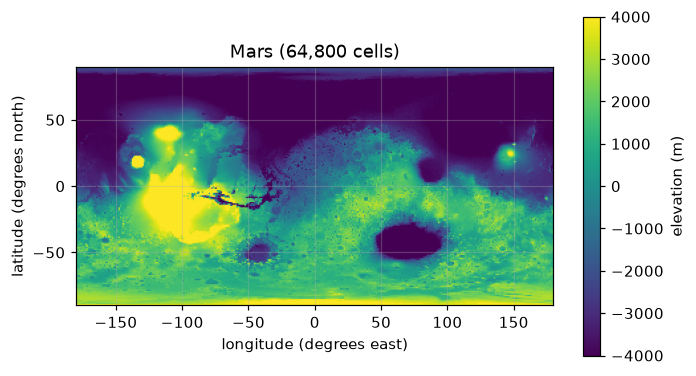

In [18]:
plt.figure(figsize=(7, 4))
plt.imshow(mars, extent=map_edges, vmin=-4000, vmax=4000)   # colours stop at ±4000 m
plt.colorbar(label="elevation (m)")
plt.xlabel("longitude (degrees east)")
plt.ylabel("latitude (degrees north)")
plt.title(f"Mars ({mars.size:,} cells)")
plt.show()

**Crustal dichotomy.** Mars's northern half sits kilometres lower than its southern half, and what made the step is still argued about.

The leading ideas are one or more giant impacts, or slow churning inside the young planet. The
next cell puts both planets on one histogram, with the same 250-metre bins.

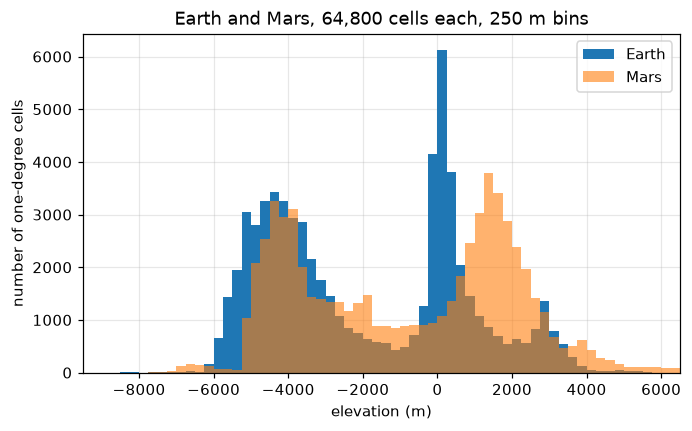

In [19]:
plt.figure(figsize=(7, 4))
plt.hist(earth.ravel(), bins=bins, label="Earth")
plt.hist(mars.ravel(), bins=bins, label="Mars", alpha=0.6)      # see-through, so Earth shows
plt.xlim(-9500, 6500)                                            # Mars's highest cells run off the right
plt.xlabel("elevation (m)")
plt.ylabel("number of one-degree cells")
plt.title(f"Earth and Mars, {earth.size:,} cells each, 250 m bins")
plt.legend()
plt.show()

### ✏️ Your turn 4

Mars has two humps too, with a trough that also takes in -1000 m. The cell below picks out
Mars's two sets of cells, split at -1000 m as you did for Earth, finds each one's level with your
`tallest_bin`, handing it the same `bins`, and prints both planets' levels and the step between each pair. Fill in the two
selections.

So: are Mars's two levels further apart than Earth's?

**Use these names**, because the self-check looks for them: `mars_deep_cells`, `mars_high_cells`,
`mars_deep` and `mars_high`.

In [20]:
mars_deep_cells = mars[mars < -1000]
mars_high_cells = mars[mars >= -1000]
mars_deep = tallest_bin(mars_deep_cells, bins)
mars_high = tallest_bin(mars_high_cells, bins)

print("Mars's two levels: ", round(mars_deep), "m and", round(mars_high), "m, a step of", round(mars_high - mars_deep), "m")
print("Earth's two levels:", round(earth_deep), "m and", round(earth_high), "m, a step of", round(earth_high - earth_deep), "m")

Mars's two levels:  -4375 m and 1375 m, a step of 5750 m
Earth's two levels: -4375 m and 125 m, a step of 4500 m


In [21]:
assert mars_deep_cells.max() < -1000 <= mars_high_cells.min(), \
    "mars_deep_cells should hold only elevations below -1000 m, and mars_high_cells only those at -1000 m or above"
assert mars_deep_cells.size + mars_high_cells.size == mars.size, \
    "between them, mars_deep_cells and mars_high_cells should hold every cell of mars: all of it below -1000 m, and all the rest"
assert mars_deep_cells.min() > -8000 and mars_high_cells.max() > 10000, \
    "the cells should be Mars's own: pick them out of mars, with a mask made from mars"
assert -4500 < mars_deep < -4250, \
    "mars_deep should be the tallest bin among mars_deep_cells"
assert 1250 < mars_high < 1500, \
    "mars_high should be the tallest bin among Mars's own cells at -1000 m or above"
print(f"✓ Mars's two levels — {mars_deep:.0f} m and {mars_high:.0f} m, {mars_high - mars_deep:.0f} m apart")

✓ Mars's two levels — -4375 m and 1375 m, 5750 m apart


## 4. Where does old ocean floor go?

An elevation grid says where the ocean floor is. It cannot say where it goes. Ocean crust sinks
back into the mantle at subduction zones, and once it is under the surface there is no height
left to measure.

An earthquake catalogue can follow it down, because it records how deep each earthquake started.

A catalogue is not a grid, for two reasons. Earthquakes happen where and when they happen, not
on a regular mesh, so position in a list means nothing. And every row carries a time, a place, a
depth and a magnitude — different kinds of thing, where a grid holds one kind.

Swap two rows of the catalogue and nothing is lost, because each row carries its own latitude.
Swap two rows of the grid and you have moved a continent.

**Table.** A table with a name on every column, so you ask for data by name instead of by position.

You have been reading tables since week 1, and `quakes` is one. Both containers report their
`.shape`, and the two numbers mean different things.

What is new today is what to do with a table you have not seen before. `.info()` is the first
thing to run: every column, its type, and how many rows are not blank. What it turns up here is
that some columns have fewer rows than others.

In [22]:
print("earth, a grid: ", earth.shape, "-", earth.size, "numbers, every one an elevation in metres")
print("quakes, a table:", quakes.shape, "-", len(quakes), "earthquakes, each with",
      quakes.shape[1], "different kinds of fact")
print()
quakes.info()

earth, a grid:  (180, 360) - 64800 numbers, every one an elevation in metres
quakes, a table: (12849, 22) - 12849 earthquakes, each with 22 different kinds of fact

<class 'pandas.DataFrame'>
RangeIndex: 12849 entries, 0 to 12848
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             12849 non-null  str    
 1   latitude         12849 non-null  float64
 2   longitude        12849 non-null  float64
 3   depth            12849 non-null  float64
 4   mag              12849 non-null  float64
 5   magType          12849 non-null  str    
 6   nst              8646 non-null   float64
 7   gap              11258 non-null  float64
 8   dmin             5630 non-null   float64
 9   rms              12681 non-null  float64
 10  net              12849 non-null  str    
 11  id               12849 non-null  str    
 12  updated          12849 non-null  str    
 13  place            12849 non-null  str    
 

`.info()` names every column and says how many rows are not blank, and the counts are not all the
same: `depth` and `place` have one for every row, `dmin` — how far away the nearest seismometer
was — has 5,630. The rows it is missing from are not empty
rows; they are earthquakes nobody recorded that number for.

**NaN.** Where the file had nothing at all, pandas puts NaN. A NaN is a hole, not a zero.

In [23]:
print(quakes[["depth", "dmin"]].head())          # the blanks in dmin print as NaN
print()
print("dmin is a hole in ", quakes["dmin"].isna().sum(), "of", len(quakes), "rows")
print("depth is a hole in", quakes["depth"].isna().sum())

complete = quakes.dropna()                       # only the rows with nothing missing, anywhere
print()
print("earthquakes deeper than 500 km:        ", (quakes["depth"] > 500).sum())
print("still there after dropna():            ", (complete["depth"] > 500).sum())
print()
print("median depth, over every row:", quakes["depth"].median(), "km - half are shallower")

   depth  dmin
0   10.0   NaN
1  582.3   NaN
2   33.0   NaN
3   33.0   NaN
4   33.0   NaN

dmin is a hole in  7219 of 12849 rows
depth is a hole in 0

earthquakes deeper than 500 km:         535
still there after dropna():             69

median depth, over every row: 21.0 km - half are shallower


`.isna()` asks "is this one a hole?" of every row at once and hands back True and False — the
same move as `earth < 0` on the grid, on a column instead. `.sum()` counts the Trues, the same way.

`.dropna()` is where it goes wrong. It throws away every row with a hole *anywhere* in it, and
this file has holes in eight columns you have no use for today. `depth` is complete, yet dropping
on the whole table takes 466 of this section's 535 deep
earthquakes with it, leaving 69. The rule is to ask for the columns you need
by name, and to drop only on those.

Most of these earthquakes are shallow: half are within 21 km of the surface,
and four in five within 70 km. The deep ones are the exception, and they are what this section is
about.

`place` names somewhere near each earthquake, with the country or region after the last comma.
`.str.split(", ")` cuts every place at its commas and `.str[-1]` keeps the last piece; assigning
that to a name the table does not have yet makes a new column. `.head()` shows a table's first
five rows, enough to check that it worked, and `.value_counts()` counts how often each value in a
column appears.

In [24]:
quakes["region"] = quakes["place"].str.split(", ").str[-1]
print(quakes[["place", "region"]].head())
print(quakes["type"].value_counts())

                         place                    region
0     west of Macquarie Island  west of Macquarie Island
1     234 km E of Levuka, Fiji                      Fiji
2    88 km ESE of Adak, Alaska                    Alaska
3  95 km ENE of Kolonga, Tonga                     Tonga
4  97 km ENE of ‘Ohonua, Tonga                     Tonga
type
earthquake           12847
nuclear explosion        1
volcanic eruption        1
Name: count, dtype: int64


### ✏️ Your turn 5

Nearly every row is an earthquake. Almost all earthquakes more than 500 km down happen inside
ocean plates sinking into the mantle, so they mark some of the places old ocean floor goes.

Picking rows works like picking cells: `quakes["mag"] >= 8` is a mask with one True or False per
row, and `quakes[quakes["mag"] >= 8]` keeps only the great earthquakes. `.groupby(column)` splits
a table into one group per value of that column, and `["depth"].count()` then counts the rows in
each group. `.sort_values()` puts a column or a set of counts in order, smallest first unless you
ask for `ascending=False`. The cell below keeps the earthquakes deeper than 500 km, counts them
region by region, and prints the six regions with the most. Fill in the mask and the column to
group by.

So: where are the earthquakes deeper than 500 km?

**Use these names**, because the self-check looks for them: `deep_quakes` and `per_region`.

In [25]:
deep_quakes = quakes[quakes["depth"] > 500]
per_region = deep_quakes.groupby("region")["depth"].count()

print(len(deep_quakes), "earthquakes deeper than 500 km")
print(per_region.sort_values(ascending=False).head(6))

535 earthquakes deeper than 500 km
region
Fiji                         123
south of the Fiji Islands    117
Fiji region                   99
Indonesia                     38
Argentina                     33
Philippines                   32
Name: depth, dtype: int64


In [26]:
assert deep_quakes["depth"].min() > 500, \
    "deep_quakes should keep only the rows deeper than 500 km: > rather than >=, because two rows sit at exactly 500.0 km"
assert 500 < len(deep_quakes) < 570, \
    "deep_quakes should keep every row deeper than 500 km and nothing shallower — the threshold is 500"
assert "Indonesia" in per_region.index, "per_region should be grouped by the region column"
assert per_region.loc["Indonesia"] > 0 and per_region.sum() == len(deep_quakes), \
    "per_region should count the rows of deep_quakes, not of quakes"
print(f"✓ deep earthquakes — {len(deep_quakes)} deeper than 500 km, in {len(per_region)} regions")

✓ deep earthquakes — 535 deeper than 500 km, in 25 regions


Three of those names are one place: Fiji, south of the Fiji Islands and Fiji region together hold
339 of the 535, where old ocean floor has sunk hundreds of kilometres into the
mantle near Fiji. Indonesia, Argentina and the Philippines follow, far behind. Earthquakes this
deep mark only some of the places where ocean floor goes down, and almost all of them lie inside
the sinking plate.

A list of names says which places. A map says where — and because every row of the catalogue
carries its own longitude and latitude, the rows go straight onto the same map section 2 drew.

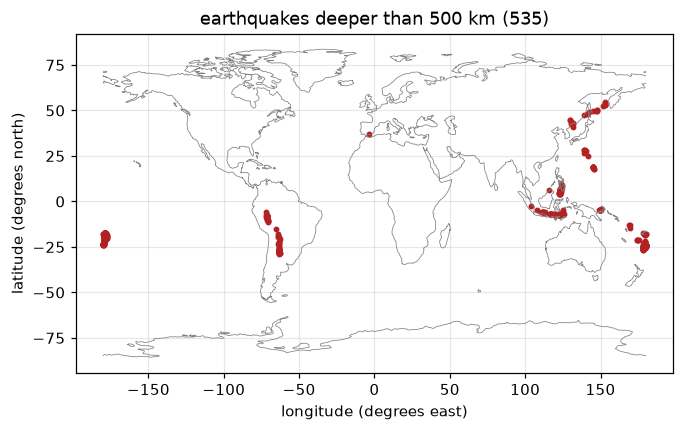

In [27]:
plt.figure(figsize=(7, 4))
plt.plot(coast.lon, coast.lat, color="grey", lw=0.5)
plt.scatter(deep_quakes["longitude"], deep_quakes["latitude"], s=8, color="firebrick")
plt.xlabel("longitude (degrees east)")
plt.ylabel("latitude (degrees north)")
plt.title(f"earthquakes deeper than 500 km ({len(deep_quakes)})")
plt.show()

Not scattered: a few short arcs. Tonga and Fiji in the southwest Pacific, cut in two by the edges
of the map because that arc straddles the date line; then Indonesia and the Philippines, Japan and
the Kuriles, and South America. Each arc is a slab of ocean floor going down.

One dot sits on its own, under southern Spain: a magnitude 6.3 at 610 km in 2010, in no arc at
all. The rule this section found holds for almost every deep earthquake, and that one is the
exception a map shows you and a table of region names does not.

Those arcs are why section 1's deep hump is as narrow as it is. Ocean floor is going back down
at them, so no piece of it stays on the surface indefinitely, and the ocean floor you measured is
the part that is still on its way from one arc to the next. Mars has no such arcs, because it
has one plate. Its low half has had nowhere to go since it was made.

## The question, answered

No. Both planets have two levels — Earth's 4,500 m apart and
Mars's 5,750 m — and they were not made the same way.

Earth's are its two kinds of crust, thin dense ocean floor and thick light continent, floating at
the two heights section 1 measured. Section 4 found the machinery that keeps them apart: ocean
floor going back down into the mantle at a handful of narrow arcs, on a planet whose plates move.

Mars's low half sits on crust that appears thinner, for a reason still argued about — a giant
impact, or convection in its mantle. Either way it happened once, to a planet with one plate, and
nothing since has moved it.

## Week 3 summary

### The science

**Earth's elevation has two peaks. So does Mars's. Same reason?**  
Earth's surface has two levels — ocean floor and continent, two kinds of crust floating at different heights. Mars has two as well, but not by Earth's mechanism: Mars has one plate and no ocean crust. What did make Mars's is still argued about — a giant impact, or convection in its mantle. A histogram's bin count can hide the science: too few bins merge real peaks. A longitude-latitude grid over-counts the poles, so area-weight before quoting any percentage of a planet's surface.

- **Two kinds of crust.** Ocean crust is thin and dense, continental crust thick and light; both float on the mantle, and the thick, light kind floats higher.
- **Crustal dichotomy.** Mars's northern half sits kilometres lower than its southern half, and what made the step is still argued about.
- **Area weighting.** A longitude-latitude grid counts every square once, but a square near the pole is a sliver; weight each row by cos(latitude) before quoting a percentage.

### The code

| Function | What it does |
|---|---|
| **NumPy** | |
| `np.array(list)` | the container that does arithmetic to every number at once |
| `grid.shape` | how many rows and columns |
| `grid.size` | how many numbers altogether |
| `grid.ravel()` | lay a grid out flat, as one long line of numbers |
| `grid.sum()` | add every number up — on a mask, that counts the Trues |
| `grid.argmax()` | the position of the largest value, not the value itself |
| `np.histogram(values, bins)` | the counts a histogram would draw, handed back as numbers instead of drawn |
| `grid[mask]` | keep only the cells where the mask is True |
| `mask & other_mask` | True only where both masks are True, the array version of and |
| **pandas** | |
| `table.info()` | every column, its type, and how many rows are not blank |
| `table.groupby(column)` | split the table into one group per value |
| `column.count() / column.median()` | how many, and the middle value |
| `table[mask]` | keep only the rows where the mask is True |
| **Matplotlib** | |
| `plt.hist(values, bins)` | draw how the numbers are spread; bins is either how many to use, or the edges to use |
| `plt.imshow(grid, extent=[...])` | draw a whole grid as a picture, one pixel per cell |
| `plt.colorbar(label=...)` | the key that says what the colours mean |

## Homework

Three parts, and the point of all three is to get comfortable with the two containers. Part 1
works a grid with masks — building them, combining them with `&`, counting them, drawing them.
Part 2 does the other thing a grid does, arithmetic on every cell at once. Part 3 works a table:
picking rows with a mask, and counting them a group at a time.

The first two go together. A planet's **low level** is everything below -1000 m — the trough
class split each planet at, in Your turn 2 and Your turn 4. Part 1 draws where that low ground
lies on each planet, and part 1's two pictures explain part 2's numbers.

In [28]:
# ── Checkpoint ── run this if you restarted the kernel or fell behind ──

# Run the setup cell at the top, then re-run your own Your turn 3, where `cell_area` and
# `area_share` are defined: they are your answer, so this cell cannot rebuild them for you.
# Everything else is rebuilt here.
earth_low = earth < -1000                               # Earth's low level, from Your turn 2
quakes["region"] = quakes["place"].str.split(", ").str[-1]   # the column section 4 made

### ✏️ Your turn 6

**Where does each planet's low ground lie?**

Your turn 2 split each planet at -1000 m and counted what fell on each side. This part draws
that split instead. A mask is a grid of True and False with the same layout as the elevations, so
`plt.imshow` can draw it the way section 1 drew `earth` itself: every low cell one colour, every
other cell the other. `cmap="Blues"` picks the two colours, dark for True.

Three names come from elsewhere. `earth_low` is Earth's low level, rebuilt in the checkpoint cell
just above. `latitude` came from the setup cell and holds every cell's latitude, so `latitude > 0`
is a mask of the northern half. And `&`, from section 1, is True only where both masks are.

Fill in Mars's mask, the grid the second picture draws, and Mars's share.

So: is the low ground spread over the planet, or is it all in one place?

**Use these names**, because the self-check looks for them: `mars_low`, `north`, `earth_north`
and `mars_north`.

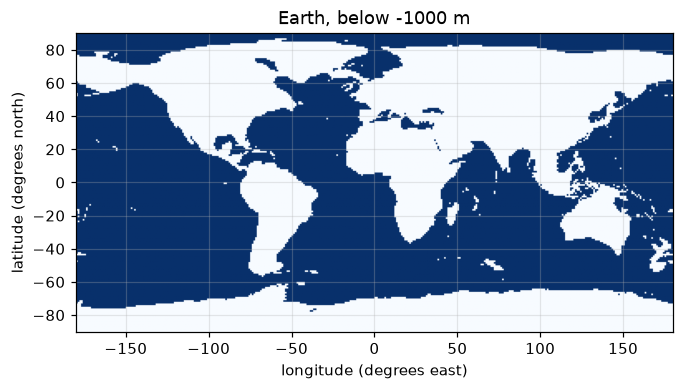

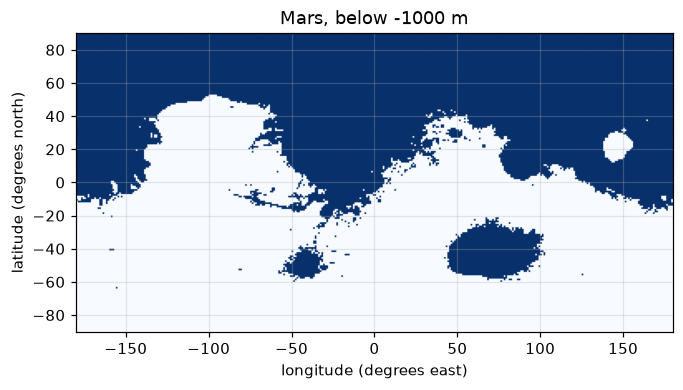

of Earth's low cells, 0.42 are north of the equator
of Mars's low cells,  0.88 are north of the equator


In [29]:
mars_low = mars < -1000                     # Mars's low level

plt.figure(figsize=(7, 4))
plt.imshow(earth_low, extent=map_edges, cmap="Blues")
plt.xlabel("longitude (degrees east)")
plt.ylabel("latitude (degrees north)")
plt.title("Earth, below -1000 m")
plt.show()

plt.figure(figsize=(7, 4))
plt.imshow(mars_low, extent=map_edges, cmap="Blues")
plt.xlabel("longitude (degrees east)")
plt.ylabel("latitude (degrees north)")
plt.title("Mars, below -1000 m")
plt.show()

north = latitude > 0                          # one True for every cell north of the equator
earth_north = (earth_low & north).sum() / earth_low.sum()
mars_north = (mars_low & north).sum() / mars_low.sum()

print("of Earth's low cells,", round(earth_north, 2), "are north of the equator")
print("of Mars's low cells, ", round(mars_north, 2), "are north of the equator")

In [30]:
assert mars_low.shape == mars.shape, \
    "mars_low should be a mask over the whole grid, one True or False per cell — mars < -1000"
assert mars[mars_low].max() < -1000, \
    "mars_low should keep only the cells below -1000 m — it is a mask over mars, not over earth"
assert mars_low.sum() > mars.size / 4, \
    "mars_low should be every low cell on Mars; nearly half the grid is below -1000 m"
assert 0.40 < earth_north < 0.44, \
    "earth_north is the share of the LOW cells that are north: (earth_low & north).sum() over earth_low.sum()"
assert 0.86 < mars_north < 0.90, \
    "mars_north is that same share for Mars — divide by mars_low.sum(), not by earth_low.sum()"
print(f"✓ Homework 1 — {earth_north:.2f} of Earth's low level is north of the equator, "
      f"against {mars_north:.2f} of Mars's")

✓ Homework 1 — 0.42 of Earth's low level is north of the equator, against 0.88 of Mars's


**What the numbers mean.** Earth's low level is the ocean floor, and the picture shows it nearly everywhere:
0.42 of it north of the equator, so very nearly half and half, in basins
that run from one polar sea to the other. Mars's is a single piece — 0.88 of
it north — one cap over most of the northern hemisphere, with a step around its edge. The two
dark patches left in the south are not part of it: the larger is Hellas, an impact basin whose
floor holds Mars's deepest point at -7,682 m, and between them they are only
0.12 of the low cells.

That is the difference this week's question is about, in one pair of pictures. Earth's two levels
are two kinds of crust, and both kinds are spread over the whole planet because plates have been
carrying them around for billions of years. Mars's two levels are one boundary, in one place.
Two planets and one boundary is not much to generalise from, which is part of why the cause of
Mars's step is still argued about.

### ✏️ Your turn 7

**What is the average height of a planet — and is that a useful thing to know?**

So far you have compared a grid with a number, which gives a mask. This part multiplies two grids
together, which is the other thing an array does to every cell at once.

An average is a sum over a count, and `earth.sum() / earth.size` is exactly that: every elevation
added up, divided by how many there are. But it counts a sliver at the pole as heavily as a square
on the equator — the problem Your turn 3 found. The weighted version multiplies every elevation by
its own cell's area first. `earth * cell_area` is that multiplication, one per cell, in one line;
adding those up and dividing by `cell_area.sum()` gives the average of the ground rather than of
the cells.

Fill in the weighted average for each planet. The block underneath is written for you: it asks
what share of Earth's surface lies within half a bin of each of three heights — the two levels
class found in Your turn 2, and the average you just worked out.

So: does weighing the cells change the average, and does it change it the same way on both planets?

**Use these names**, because the self-check looks for them: `earth_weighted` and `mars_weighted`.

In [31]:
earth_flat = earth.sum() / earth.size          # every cell counted once
mars_flat = mars.sum() / mars.size

earth_weighted = (earth * cell_area).sum() / cell_area.sum()
mars_weighted = (mars * cell_area).sum() / cell_area.sum()

print("Earth's average height:", round(earth_flat), "m by cells,", round(earth_weighted), "m by area")
print("Mars's average height: ", round(mars_flat), "m by cells,", round(mars_weighted), "m by area")
print()
for name, level in [("the deep level", -4375), ("the high level", 125),
                    ("this average", earth_weighted)]:
    band = (earth >= level - 125) & (earth < level + 125)
    share = cell_area[band].sum() / cell_area.sum()
    print("share of Earth within 125 m of", name + ":", round(share, 3))

Earth's average height: -1882 m by cells, -2389 m by area
Mars's average height:  -735 m by cells, -568 m by area

share of Earth within 125 m of the deep level: 0.059
share of Earth within 125 m of the high level: 0.092
share of Earth within 125 m of this average: 0.012


In [32]:
assert -2450 < earth_weighted < -2330, \
    "earth_weighted is (earth * cell_area).sum() divided by cell_area.sum() — the ground's average, not the cells'"
assert -610 < mars_weighted < -520, \
    "mars_weighted is that same average for Mars — multiply MARS by cell_area"
assert earth_weighted < earth_flat and mars_weighted > mars_flat, \
    "weighing should pull Earth's average DOWN and Mars's UP; if both moved the same way, check which grid each line multiplies"
print(f"✓ Homework 2 — weighing the cells moves Earth's average by {earth_weighted - earth_flat:+.0f} m "
      f"and Mars's by {mars_weighted - mars_flat:+.0f} m")

✓ Homework 2 — weighing the cells moves Earth's average by -506 m and Mars's by +167 m


**What the numbers mean.** Weighing the cells moves Earth's average down by 506 m and
Mars's up by 167 m — half a kilometre on Earth, and in the
opposite direction on Mars. Part 1's two pictures are the reason. Counting cells over-weighs the
rows near the poles; Earth keeps its high ground there, Greenland and Antarctica, so counting
cells makes Earth look higher than it is, while Mars keeps its low cap there, so counting cells
makes Mars look lower. The correction is a fact about where a planet's ground sits, not a fixed
number you can borrow from one planet for another.

Then look at the three shares. Within 125 m of Earth's average lies 0.012 of the
surface, against 0.059 at the deep level and 0.092 at the high one.
The average height of Earth is a height almost none of Earth is at: it falls in the trough between
the two humps, which is what a two-peaked distribution does to an average. A single number is the
wrong summary of this planet, and the histogram in section 1 is the right one.

### ✏️ Your turn 8

**Do the deep earthquakes come from the same places as the shallow ones?**

Your turn 5 kept the rows deeper than 500 km and counted them region by region. Two moves did it:
`quakes[mask]` keeps the rows where a mask is True, and `.groupby("region")["depth"].count()`
counts them one region at a time. `region` is the column section 4 made out of `place`; the
checkpoint cell above rebuilds it.

This part asks the same of two sets of rows — those, and the earthquakes less than 70 km down,
which are 0.81 of the catalogue. Rather than write that counting out twice,
write it once as `top_regions(rows, how_many)`, the way Your turn 2 and Your turn 3 wrote their
measurements once: everything it works on comes in through its brackets, so it does not care
which half of the catalogue it is handed. Fill in the counting line and the two masks.

So: are the deep earthquakes a sample of where earthquakes happen, or their own short list?

**Use these names**, because the self-check looks for them: `top_regions`, `shallow`, `deep`,
`shallow_top` and `deep_top`.

In [33]:
def top_regions(rows, how_many):
    """the regions holding the most of these earthquakes, the biggest first"""
    counts = rows.groupby("region")["depth"].count()     # one count for each region in `rows`
    return counts.sort_values(ascending=False).head(how_many)


shallow = quakes[quakes["depth"] < 70]
deep = quakes[quakes["depth"] > 500]

shallow_top = top_regions(shallow, 5)
deep_top = top_regions(deep, 5)

print(len(shallow), "shallow earthquakes, in", len(shallow["region"].value_counts()), "regions")
print(shallow_top)
print(len(deep), "deep earthquakes, in", len(deep["region"].value_counts()), "regions")
print(deep_top)

10465 shallow earthquakes, in 290 regions
region
Indonesia           1189
Japan                797
Papua New Guinea     659
Tonga                423
Chile                416
Name: depth, dtype: int64
535 deep earthquakes, in 25 regions
region
Fiji                         123
south of the Fiji Islands    117
Fiji region                   99
Indonesia                     38
Argentina                     33
Name: depth, dtype: int64


In [34]:
assert shallow["depth"].max() < 70 and deep["depth"].min() > 500, \
    "shallow keeps the rows less than 70 km down and deep the rows deeper than 500 km"
assert len(shallow_top) == 5 and len(deep_top) == 5, \
    "each should be the five regions with the most — group by region, count, sort, then head(5)"
assert len(shallow["region"].value_counts()) > 8 * len(deep["region"].value_counts()), \
    "the shallow earthquakes should reach far more regions than the deep ones"
assert len(set(shallow_top.index) & set(deep_top.index)) <= 2, \
    "the two top fives should barely overlap — is deep_top grouped on the DEEP rows?"
print(f"✓ Homework 3 — shallow earthquakes come from {len(shallow['region'].value_counts())} regions and deep "
      f"ones from {len(deep['region'].value_counts())}; the two top fives share "
      f"{len(set(shallow_top.index) & set(deep_top.index))} of five names")

✓ Homework 3 — shallow earthquakes come from 290 regions and deep ones from 25; the two top fives share 1 of five names


**What the numbers mean.** The shallow earthquakes reach 290 regions and the deep ones
25, and the two top fives have one name in common. Shallow earthquakes happen
almost anywhere two plates meet, which is most of the edges of most plates. Deep ones need a slab
of ocean floor that has already sunk hundreds of kilometres, and only a handful of places have
one — which is why three of the deep top five are the same arc near Fiji.

So the deep earthquakes are not a sample of where earthquakes happen; they are their own short
list, and that list is a map of where ocean floor is going down. A region name is a coarse label,
though — it is whatever the catalogue writes after the last comma — so these counts show the
pattern and would not settle where one subduction zone ends and the next begins.